### MTCNN y FaceNet Face Detection

In [ ]:
### Libraries fro MTCNN Y FaceNet

import os
import sys




In [1]:
import numpy as np
import cv2
from mtcnn.mtcnn import MTCNN
import matplotlib.pyplot as plt

detector = MTCNN()

### Detect faces in an image using MTCNN
def detect_faces(detector, image):
    results = detector.detect_faces(image)
    return results # bbox, confidence, keypoints


2026-05-11 16:44:22.910652: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-11 16:44:23.018933: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/ulises-calderon/miniconda3/envs/facenet-env/lib/python3.7/site-packages/cv2/../../lib64:
2026-05-11 16:44:23.018956: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-05-11 16:44:23.048417: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin

1/1 [==============================] - 0s 21ms/step
[{'box': [1009, 948, 1306, 1731], 'confidence': 0.9999998211860657, 'keypoints': {'left_eye': (1524, 1557), 'right_eye': (2079, 1621), 'nose': (1901, 1865), 'mouth_left': (1564, 2218), 'mouth_right': (2018, 2260)}}]
1/1 [==============================] - 1s 1s/step
[array([ 0.29446346,  0.52512   ,  0.6865226 ,  0.09027339, -0.12091468,
        0.742025  ,  1.6374192 , -1.4393702 , -0.842438  ,  0.3221797 ,
       -1.7199436 ,  1.7665405 , -0.92666763, -1.1350527 ,  1.2579595 ,
        0.4752463 ,  0.23154753,  1.048332  ,  0.9814521 , -1.0800155 ,
       -0.97418785, -0.36737207,  0.42323318, -2.3550758 , -0.9878301 ,
       -0.21372113,  2.3088794 ,  0.33692485, -1.9653919 ,  1.1468827 ,
       -2.1530695 ,  1.328235  ,  1.0334644 ,  0.2631582 ,  0.1614751 ,
       -1.0773809 , -0.3031052 , -0.82179195, -0.9105132 , -0.8751906 ,
        0.40167776, -0.36625716, -2.579333  ,  0.13638258,  1.0626583 ,
       -1.9438496 , -0.08005224, 

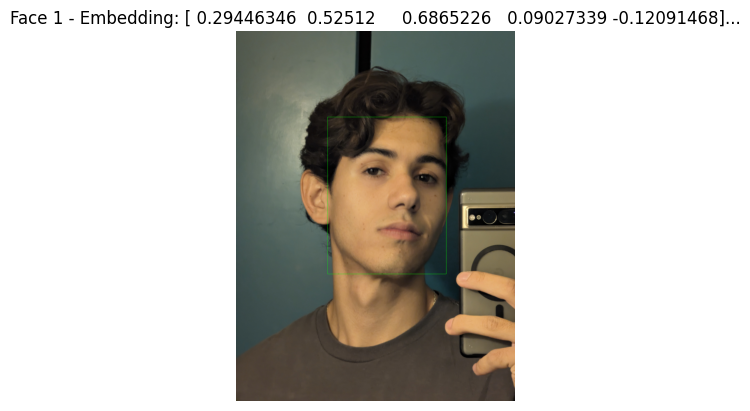

In [ ]:
### Get embeddings from FaceNet

import tensorflow as tf
from tensorflow.keras.models import load_model

model = load_model('model/facenet_keras.h5', compile=False)

def get_embedding(model, face_pixels):
    face_pixels = face_pixels.astype('float32')
    mean, std = face_pixels.mean(), face_pixels.std()
    face_pixels = (face_pixels - mean) / std
    samples = np.expand_dims(face_pixels, axis=0)
    samples = tf.image.resize(samples, (160, 160))
    # ValueError: Input 0 of layer "inception_resnet_v1" is incompatible with the layer: expected shape=(None, 160, 160, 3), found shape=(None, 1731, 1306, 3)
    yhat = model.predict(samples)
    return yhat[0]


# test_image = cv2.imread('images/Ulises/PXL_20250911_174349135.jpg')
# test_image_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
# faces = detect_faces(detector, test_image_rgb)
# print(faces)
# embeddings = []
# for face in faces:
#     x, y, width, height = face['box']
#     face_pixels = test_image_rgb[y:y+height, x:x+width]
#     embedding = get_embedding(model, face_pixels)
#     embeddings.append(embedding)

# print(embeddings)

# ## ### Visualize detected faces and embeddings
# for i, face in enumerate(faces):
#     x, y, width, height = face['box']
#     cv2.rectangle(test_image_rgb, (x, y), (x + width, y + height), (0, 255, 0), 2)
#     plt.imshow(test_image_rgb)
#     plt.title(f'Face {i+1} - Embedding: {embeddings[i][:5]}...') # Show first 5 values of embedding
#     plt.axis('off')
#     plt.show()


In [8]:
### Construct paths to the dataset and the face detector model
import os
# !pip install pandas
import pandas as pd

base_dir = "images"

class_image_paths = {
    clase: [
        os.path.join(base_dir, clase, archivo)
        for archivo in sorted(os.listdir(os.path.join(base_dir, clase)))
        if archivo.lower().endswith(".jpg") or archivo.lower().endswith(".jpeg")
    ]
    for clase in sorted(os.listdir(base_dir))
    if os.path.isdir(os.path.join(base_dir, clase))
}

# Construct embeddings in a pandas DataFrame
data = []
for clase, image_paths in class_image_paths.items():
    for image_path in image_paths:
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        faces = detect_faces(detector, image_rgb)
        if len(faces) > 0:
            x, y, width, height = faces[0]['box']
            face_pixels = image_rgb[y:y+height, x:x+width]
            embedding = get_embedding(model, face_pixels)
            data.append({'class': clase, 'embedding': embedding})

df = pd.DataFrame(data)
save_path = 'data/embeddings.csv'
df.to_csv(save_path, index=False)
print(f"Embeddings saved to {save_path}")

1/1 [==============================] - 0s 42ms/step
Embeddings saved to data/embeddings.csv


In [10]:
# Train a classifier (e.g., SVM) using the embeddings in the DataFrame
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
X = np.array(df['embedding'].tolist())
y = df['class'].values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
classifier = SVC(kernel='linear', probability=True)
classifier.fit(X_train, y_train)
accuracy = classifier.score(X_test, y_test)
print(f"Classifier accuracy: {accuracy:.2f}")


Classifier accuracy: 1.00


In [11]:
# Test live webcam feed
import cv2
cap = cv2.VideoCapture(0)


while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    faces = detect_faces(detector, frame_rgb)
    for face in faces:
        x, y, width, height = face['box']
        face_pixels = frame_rgb[y:y+height, x:x+width]
        embedding = get_embedding(model, face_pixels)
        embedding_reshaped = embedding.reshape(1, -1)
        probabilities = classifier.predict_proba(embedding_reshaped)[0]
        predicted_class_index = np.argmax(probabilities)
        predicted_class_label = label_encoder.inverse_transform([predicted_class_index])[0]
        confidence = probabilities[predicted_class_index]
        cv2.rectangle(frame, (x, y), (x + width, y + height), (0, 255, 0), 2)
        cv2.putText(frame, f"{predicted_class_label} ({confidence:.2f})", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    cv2.imshow('Webcam Face Recognition', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

1/1 [==============================] - 0s 41ms/step


QFontDatabase: Cannot find font directory /home/ulises-calderon/miniconda3/envs/facenet-env/lib/python3.7/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ulises-calderon/miniconda3/envs/facenet-env/lib/python3.7/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ulises-calderon/miniconda3/envs/facenet-env/lib/python3.7/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ulises-calderon/miniconda3/envs/facenet-env/lib/python3.7/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for ex

1/1 [==============================] - 0s 43ms/step
